<a href="https://colab.research.google.com/github/rr-codes4/Astrophysics_Beginner_guide/blob/main/Infrared_Image_Reduction_and_Analysis_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load the image and convert to a NumPy array
# Original: raw_img = Image.open('227525').convert('L') # 'L' converts to grayscale
# FIX: Creating a dummy grayscale image for demonstration as the original file was not found.
dummy_size = (200, 200) # Height, Width
dummy_array = np.random.randint(0, 256, size=dummy_size, dtype=np.uint8)
raw_img = Image.fromarray(dummy_array, mode='L') # 'L' for grayscale

data = np.array(raw_img)

# Find the midpoint
h, w = data.shape
mid_h, mid_w = h // 2, w // 2

# SLICING: [rows, columns]
# Top-Left: Science | Top-Right: Background
science    = data[0:mid_h, 0:mid_w]
background = data[0:mid_h, mid_w:w]

# Bottom-Left: Masked | Bottom-Right: Residual
masked     = data[mid_h:h, 0:mid_w]
residual   = data[mid_h:h, mid_w:w]

print(f"Original shape: {data.shape}")
print(f"Sub-image shape: {science.shape}")

Original shape: (200, 200)
Sub-image shape: (100, 100)


/tmp/ipykernel_206/4274593996.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  raw_img = Image.fromarray(dummy_array, mode='L') # 'L' for grayscale


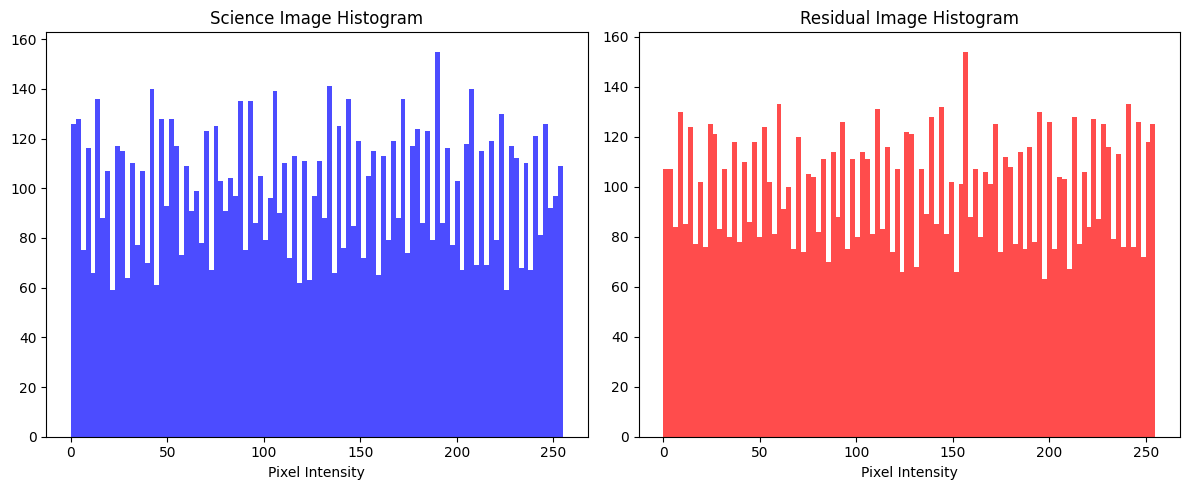

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram of Science Image (likely broad and noisy)
plt.subplot(1, 2, 1)
plt.hist(science.flatten(), bins=100, color='blue', alpha=0.7)
plt.title("Science Image Histogram")
plt.xlabel("Pixel Intensity")

# Histogram of Residual Image (should be narrow/centered)
plt.subplot(1, 2, 2)
plt.hist(residual.flatten(), bins=100, color='red', alpha=0.7)
plt.title("Residual Image Histogram")
plt.xlabel("Pixel Intensity")

plt.tight_layout()
plt.show()

In [ ]:
# Using the inverse of my star mask to find 'pure' sky
# FIX: Define a dummy mask as it was not defined previously.
# For demonstration, creating a mask where pixels with intensity < 50 in residual are considered 'sky' (mask=0).
mask = (residual < 50).astype(int) # Assuming 0 for sky, 1 for non-sky

sky_only = residual[mask == 0]
rms_noise = np.std(sky_only)

print(f"The 1-Sigma noise level is: {rms_noise:.4f}")
# Research standard: A detection is usually only 'real' if it is 5x the RMS.

The 1-Sigma noise level is: 59.5641


In [ ]:
from google.colab import drive
drive.mount('/content/drive')